<a href="https://colab.research.google.com/github/Akhilp12346/Book_analysis_with_python/blob/main/Book_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# importing liabraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# Readind csv files
df = pd.read_csv("/Books_Data_Clean.csv")

In [ ]:
# Show top 5 rows
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [ ]:
# Decription of datasets
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [ ]:
# Updating negative values
df = df[df["Publishing Year"] > 1900]

In [ ]:
# check the duplicates values in every coloums
df.isna().sum()

,0
index,0
Publishing Year,0
Book Name,0
Author,0
language_code,47
Author_Rating,0
Book_average_rating,0
Book_ratings_count,0
genre,0
gross sales,0


In [ ]:
# dropping the duplicates from column
df.dropna(subset = 'Book Name', inplace= True)

In [ ]:
# show total duplicate value in each column
df.duplicated().sum()

np.int64(0)

In [ ]:
# show the unique value in every column
df.nunique()

,0
index,988
Publishing Year,101
Book Name,987
Author,669
language_code,8
Author_Rating,4
Book_average_rating,133
Book_ratings_count,983
genre,4
gross sales,774


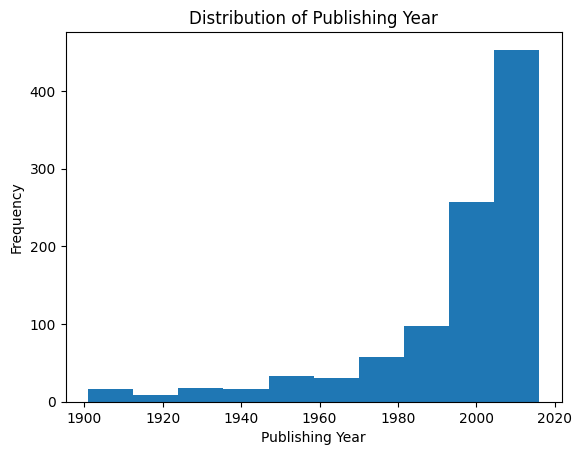

In [ ]:
# histogram charts
import matplotlib.pyplot as plt

plt.hist(df["Publishing Year"])
plt.xlabel("Publishing Year")
plt.ylabel("Frequency")
plt.title("Distribution of Publishing Year")
plt.show()

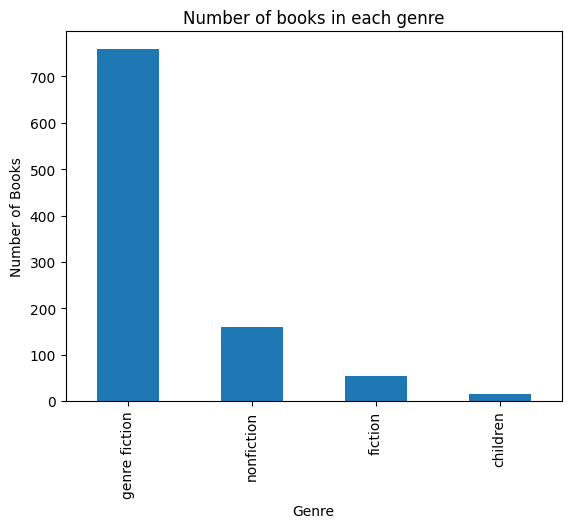

In [ ]:
# Bar plot of each genre
df["genre"].value_counts().plot(kind ="bar")
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.title("Number of books in each genre")
plt.show()

In [ ]:
# group by Author column and find the mean of Book_average_rating
df.groupby("Author")["Book_average_rating"].mean().sort_values(ascending=False).head()

,Book_average_rating
Author,
Bill Watterson,4.650
"Bill Watterson, G.B. Trudeau",4.610
J.R.R. Tolkien,4.590
George R.R. Martin,4.560
Sarah J. Maas,4.526


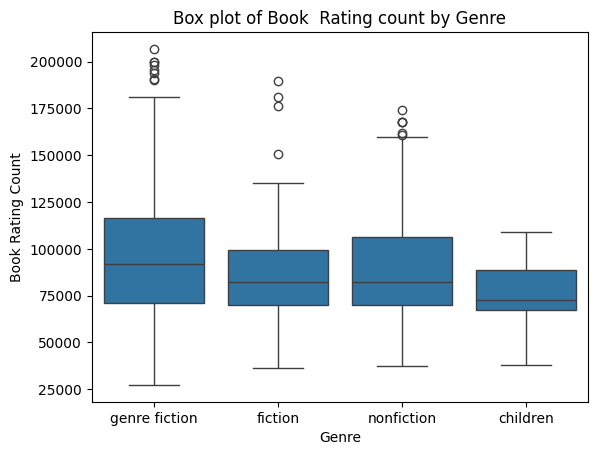

In [ ]:
# Boxplot of Book rating count for each genre
import seaborn as sns
sns.boxplot(x="genre", y="Book_ratings_count", data=df)
plt.xlabel("Genre")
plt.ylabel("Book Rating Count")
plt.title("Box plot of Book  Rating count by Genre")
plt.show()

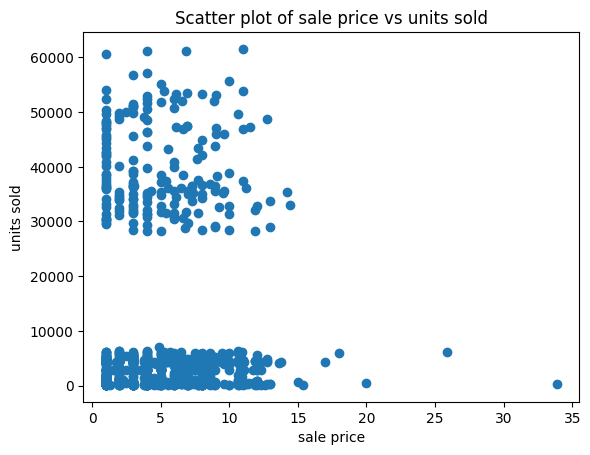

In [ ]:
# Scatter plot of sale price vs units sold
plt.scatter(df["sale price"],df["units sold"])
plt.xlabel("sale price")
plt.ylabel("units sold")
plt.title("Scatter plot of sale price vs units sold")
plt.show()

In [ ]:
# sorting and counting the values in language_code column
df["language_code"].value_counts().sort_values(ascending=True)

,count
language_code,
nl,1
spa,2
ara,2
fre,4
en-CA,7
en-GB,29
en-US,226
eng,717


In [ ]:
language_Counts = df["language_code"].value_counts()

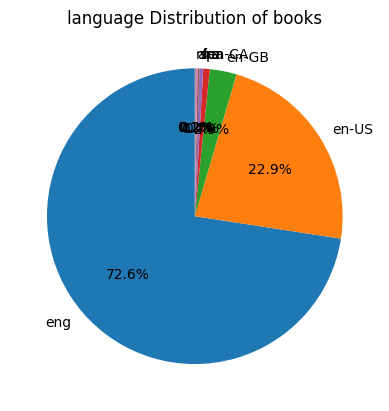

In [ ]:
# pie chart by language distribution of books
plt.pie(language_Counts, labels=language_Counts.index,startangle=90,autopct="%1.1f%%")
plt.title("language Distribution of books")
plt.show()

In [ ]:
df.columns

Index(['index', 'Publishing Year', 'Book Name', 'Author', 'language_code',
       'Author_Rating', 'Book_average_rating', 'Book_ratings_count', 'genre',
       'gross sales', 'publisher revenue', 'sale price', 'sales rank',
       'Publisher ', 'units sold'],
      dtype='object')

In [ ]:
# Group by Publisher  and total revenue of publisher by Desc order
df.groupby("Publisher ")["publisher revenue"].sum().sort_values(ascending=False)

,publisher revenue
Publisher,
Penguin Group (USA) LLC,191581.104
Random House LLC,174956.244
"Amazon Digital Services, Inc.",141767.772
HarperCollins Publishers,121769.814
Hachette Book Group,107410.968
Simon and Schuster Digital Sales Inc,46858.206
Macmillan,31249.830
HarperCollins Publishing,2830.806
HarperCollins Christian Publishing,2135.670


In [ ]:
# group by Author_Rating and average of Book_ratings_count by each author
df.groupby("Author_Rating")["Book_ratings_count"].mean().sort_values(ascending=False)

,Book_ratings_count
Author_Rating,
Intermediate,101400.272569
Famous,98295.250000
Novice,87318.464286
Excellent,83804.800595


In [ ]:
df.columns

Index(['index', 'Publishing Year', 'Book Name', 'Author', 'language_code',
       'Author_Rating', 'Book_average_rating', 'Book_ratings_count', 'genre',
       'gross sales', 'publisher revenue', 'sale price', 'sales rank',
       'Publisher ', 'units sold'],
      dtype='object')

In [ ]:
# group by language_code and no of books in each language
df.groupby("language_code").size().sort_values(ascending=False)

,0
language_code,
eng,717
en-US,226
en-GB,29
en-CA,7
fre,4
ara,2
spa,2
nl,1


In [ ]:
'''we can find max,min,median,std and var of Book_ratings_count by grouping with
Author_Rating'''

df.groupby("Author_Rating")["Book_ratings_count"].max()


,Book_ratings_count
Author_Rating,
Excellent,167848
Famous,206792
Intermediate,199872
Novice,155903


In [ ]:
df.groupby("Author_Rating")["Book_ratings_count"].min()

,Book_ratings_count
Author_Rating,
Excellent,32626
Famous,54977
Intermediate,27308
Novice,42339


In [ ]:
df.groupby("Author_Rating")["Book_ratings_count"].median()

,Book_ratings_count
Author_Rating,
Excellent,81609.5
Famous,90527.0
Intermediate,98254.5
Novice,77446.5


In [ ]:
df.groupby("Author_Rating")["Book_ratings_count"].std()

,Book_ratings_count
Author_Rating,
Excellent,21023.456069
Famous,35036.475144
Intermediate,34210.096082
Novice,30859.612389


In [ ]:
df.groupby("Author_Rating")["Book_ratings_count"].var()

,Book_ratings_count
Author_Rating,
Excellent,4.419857e+08
Famous,1.227555e+09
Intermediate,1.170331e+09
Novice,9.523157e+08


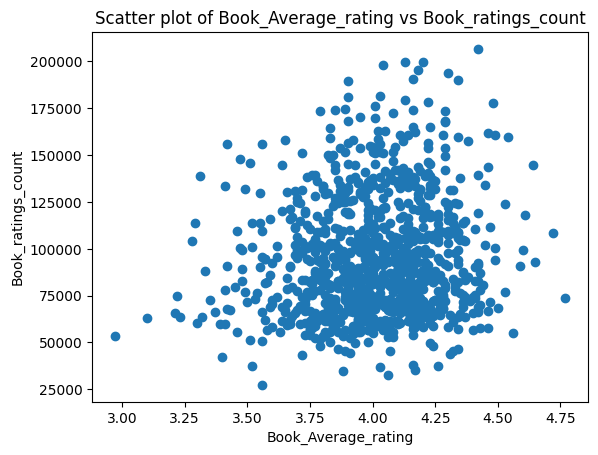

In [ ]:
# scatter plot Book_Average_rating vs Book_ratings_count
plt.scatter(df["Book_average_rating"],df["Book_ratings_count"])
plt.xlabel("Book_Average_rating")
plt.ylabel("Book_ratings_count")
plt.title("Scatter plot of Book_Average_rating vs Book_ratings_count")
plt.show()

In [21]:
# total gross sale by each Author
total_gross_Sale = df.groupby("Author")["gross sales"].sum()

Text(0.5, 1.0, 'Total Gross Sale by Author')

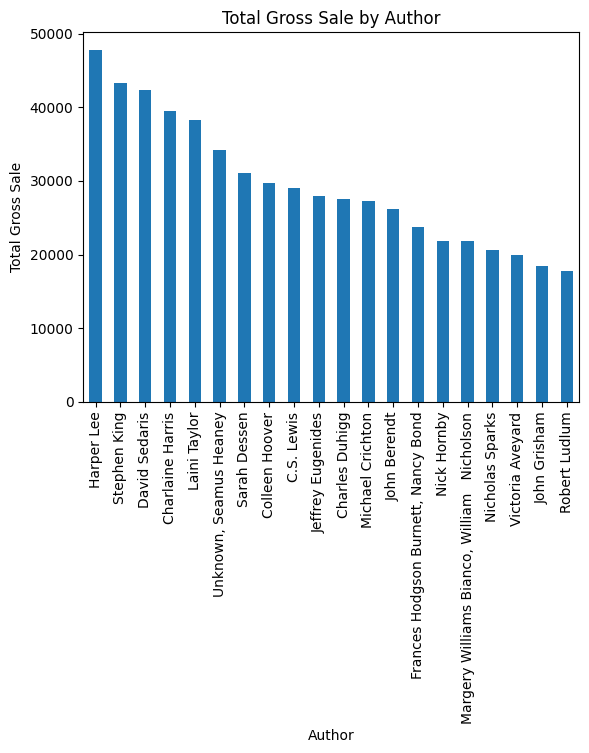

In [ ]:
total_gross_Sale.sort_values(ascending=False).head(20).plot(kind="bar")
plt.xlabel("Author")
plt.ylabel("Total Gross Sale")
plt.title("Total Gross Sale by Author")

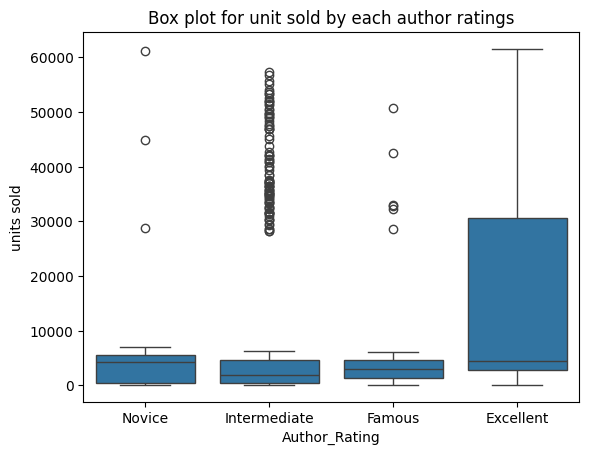

In [ ]:
# box plot for unit sold by each author ratings
sns.boxplot(x="Author_Rating", y="units sold", data=df)
plt.xlabel("Author_Rating")
plt.ylabel("units sold")
plt.title("Box plot for unit sold by each author ratings")
plt.show()

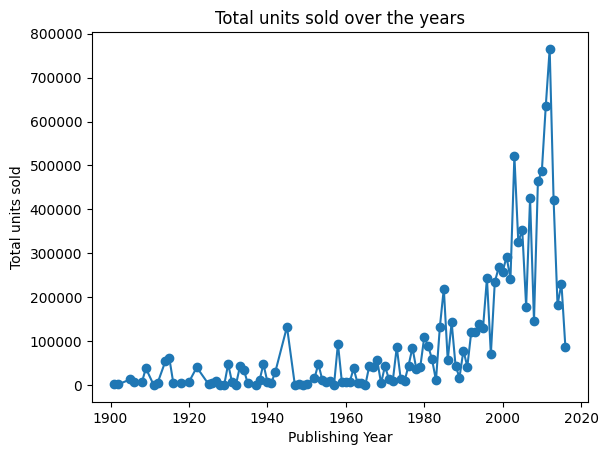

In [ ]:
# total unit sold over the years
from matplotlib import markers

df.groupby("Publishing Year")["units sold"].sum().plot(kind="line", marker = "o")
plt.xlabel("Publishing Year")
plt.ylabel("Total units sold")
plt.title("Total units sold over the years")
plt.show()